## Baseline Model

In this section, I build a simple baseline model that will be used as the first\
reference point for later comparison. The goal here is not to create the best model,\
but to build a basic benchmark.

This baseline also helps show where the model performs poorly. By looking at its errors,\
we can better understand what is missing and use those insights later in the EDA and feature\
engineering steps.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
DATA_CODE_DIR = Path().resolve().parent / "01_data"

if str(DATA_CODE_DIR) not in sys.path:
    sys.path.append(str(DATA_CODE_DIR))

from load_data import load_stock_data

In [3]:
df = load_stock_data()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (19836, 8)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL


Our data

In [4]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum())

print("\nTickers:")
print(df["Ticker"].unique())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

<class 'pandas.DataFrame'>
RangeIndex: 19836 entries, 0 to 19835
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       19836 non-null  datetime64[us]
 1   Open       19836 non-null  float64       
 2   High       19836 non-null  float64       
 3   Low        19836 non-null  float64       
 4   Close      19836 non-null  float64       
 5   Adj Close  19836 non-null  float64       
 6   Volume     19836 non-null  int64         
 7   Ticker     19836 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(1), str(1)
memory usage: 1.2 MB
None

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

Tickers:
<StringArray>
['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
Length: 5, dtype: str

Date range:
2010-01-04 00:00:00 to 2026-04-02 00:00:00


In [5]:
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL


Data looks clean and tidy

In [6]:
df_model = df.copy()

# Daily return
df_model["Return_1d"] = df_model.groupby("Ticker")["Close"].pct_change(1)

# Lagged returns
df_model["Return_3d"] = df_model.groupby("Ticker")["Close"].pct_change(3)
df_model["Return_5d"] = df_model.groupby("Ticker")["Close"].pct_change(5)

# Rolling volatility
df_model["Volatility_5d"] = (
    df_model.groupby("Ticker")["Return_1d"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

# Volume change
df_model["Volume_Change_1d"] = df_model.groupby("Ticker")["Volume"].pct_change(1)

# Target = next-day return
df_model["Target_Return_1d"] = (
    df_model.groupby("Ticker")["Close"]
    .pct_change(1)
    .shift(-1)
)

df_model.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volume_Change_1d,Target_Return_1d
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,0.001729
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,0.219098,-0.015906
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,-0.082646,-0.001849
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016027,NaN,NaN,-0.135882,0.006648
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,-0.061871,-0.008821
5,2010-01-11,7.600000,7.607143,7.444643,7.503929,6.295528,462229600,AAPL,-0.008821,-0.004076,-0.018223,0.008877,0.032660,-0.011375
6,2010-01-12,7.471071,7.491786,7.372143,7.418571,6.223914,594459600,AAPL,-0.011375,-0.013582,-0.031066,0.008830,0.286070,0.014106
7,2010-01-13,7.423929,7.533214,7.289286,7.523214,6.311707,605892000,AAPL,0.014106,-0.006274,-0.001517,0.010647,0.019232,-0.005792
8,2010-01-14,7.503929,7.516429,7.465000,7.479643,6.275150,432894000,AAPL,-0.005792,-0.003236,-0.005461,0.010937,-0.285526,-0.016712
9,2010-01-15,7.533214,7.557143,7.352500,7.354643,6.170283,594067600,AAPL,-0.016712,-0.008617,-0.028540,0.011784,0.372317,0.044238


At this stage, we create the first baseline features from historical price and\
volume data to prepare the dataset for prediction. The target is set as the\
next-day return so the model learns to predict the following day’s stock movement.

In [7]:
feature_cols = [
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volume_Change_1d"
]

target_col = "Target_Return_1d"

print(df_model[feature_cols + [target_col]].isna().sum())

Return_1d            5
Return_3d           15
Return_5d           25
Volatility_5d       25
Volume_Change_1d     5
Target_Return_1d     5
dtype: int64


At this stage, we check how many missing values appear in the baseline features.\
These missing values are expected because of lagged returns, rolling volatility\
and the next-day target

In [8]:
df_model = df_model.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

print(df_model.shape)
df_model.head()

(19806, 14)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volume_Change_1d,Target_Return_1d
0,2010-01-11,7.600000,7.607143,7.444643,7.503929,6.295528,462229600,AAPL,-0.008821,-0.004076,-0.018223,0.008877,0.032660,-0.011375
1,2010-01-12,7.471071,7.491786,7.372143,7.418571,6.223914,594459600,AAPL,-0.011375,-0.013582,-0.031066,0.008830,0.286070,0.014106
2,2010-01-13,7.423929,7.533214,7.289286,7.523214,6.311707,605892000,AAPL,0.014106,-0.006274,-0.001517,0.010647,0.019232,-0.005792
3,2010-01-14,7.503929,7.516429,7.465000,7.479643,6.275150,432894000,AAPL,-0.005792,-0.003236,-0.005461,0.010937,-0.285526,-0.016712
4,2010-01-15,7.533214,7.557143,7.352500,7.354643,6.170283,594067600,AAPL,-0.016712,-0.008617,-0.028540,0.011784,0.372317,0.044238


In [9]:
df_model[target_col].describe()

count    19806.000000
mean         0.000966
std          0.019449
min         -0.263901
25%         -0.008179
50%          0.000842
75%          0.010555
max          0.296115
Name: Target_Return_1d, dtype: float64

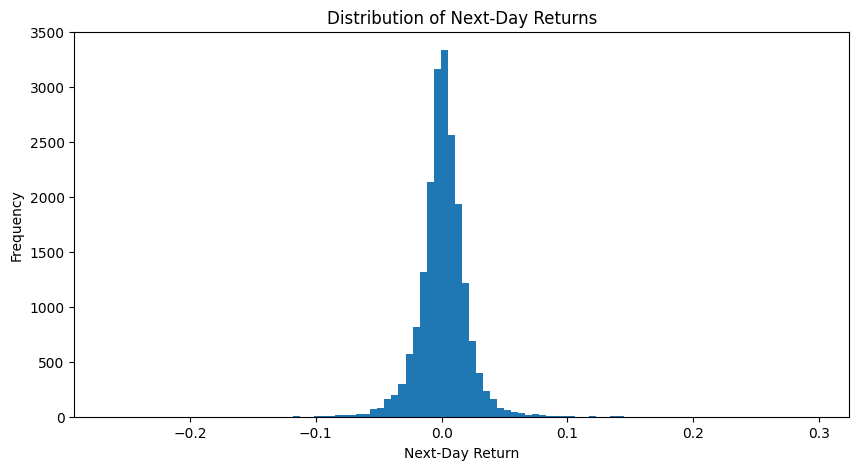

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df_model[target_col], bins=100)
plt.title("Distribution of Next-Day Returns")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.show()

#### Some take-away
The results show that most returns are concentrated close to zero, while a few large\
positive and negative moves create long tails, which is expected in financial data.

In [11]:
split_date = df_model["Date"].quantile(0.80)

train_df = df_model[df_model["Date"] <= split_date].copy()
test_df = df_model[df_model["Date"] > split_date].copy()

print("Split date:", split_date)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Split date: 2023-02-02 00:00:00
Train shape: (15846, 14)
Test shape: (3960, 14)


In [12]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [13]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [14]:
train_preds = baseline_model.predict(X_train)
test_preds = baseline_model.predict(X_test)

In [15]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def evaluate_regression(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    direction_acc = directional_accuracy(y_true, y_pred)

    print(f"--- {dataset_name} ---")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²: {r2:.6f}")
    print(f"Directional Accuracy: {direction_acc:.4f}")
    print()

At this stage, we define evaluation functions to measure how well the regression\
model predicts next-day returns.  

In [16]:
evaluate_regression(y_train, train_preds, "Train")
evaluate_regression(y_test, test_preds, "Test")

--- Train ---
MAE: 0.013213
RMSE: 0.019621
R²: 0.002486
Directional Accuracy: 0.5232

--- Test ---
MAE: 0.012969
RMSE: 0.018643
R²: -0.000681
Directional Accuracy: 0.5364



Evaluate the baseline model on both the training and test sets\
using regression error metrics and directional accuracy. The results\
show that the model explains very little of the return variation, but\
it predicts the direction of price movement little better than random.

In [17]:
test_results = test_df.copy()
test_results["Predicted_Return"] = test_preds
test_results["Residual"] = test_results[target_col] - test_results["Predicted_Return"]
test_results["Absolute_Error"] = np.abs(test_results["Residual"])

test_results.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volume_Change_1d,Target_Return_1d,Predicted_Return,Residual,Absolute_Error
3289,2023-02-03,148.029999,157.380005,147.830002,154.500000,152.061539,154357300,AAPL,0.024400,0.070760,0.058727,0.021424,0.304365,-0.017929,-0.000545,-0.017384,0.017384
3290,2023-02-06,152.570007,153.100006,150.779999,151.729996,149.335236,69858300,AAPL,-0.017929,0.043320,0.061049,0.020635,-0.547425,0.019245,0.001045,0.018200,0.018200
3291,2023-02-07,150.639999,155.229996,150.639999,154.649994,152.209183,83322600,AAPL,0.019245,0.025394,0.071800,0.020761,0.192737,-0.017653,-0.000163,-0.017490,0.017490
3292,2023-02-08,153.880005,154.580002,151.169998,151.919998,149.522263,64120100,AAPL,-0.017653,-0.016699,0.044626,0.025324,-0.230460,-0.006912,0.001233,-0.008144,0.008144
3293,2023-02-09,153.779999,154.330002,150.419998,150.869995,148.488800,56007100,AAPL,-0.006912,-0.005668,0.000331,0.020287,-0.126528,0.000928,0.001089,-0.000161,0.000161


As we create a test results table with actual returns, predicted returns,\
residuals, and absolute errors to inspect individual predictions\
and see where the baseline model makes larger mistakes.

In [18]:
stock_metrics = []

for ticker in test_results["Ticker"].unique():
    temp = test_results[test_results["Ticker"] == ticker]

    mae = mean_absolute_error(temp[target_col], temp["Predicted_Return"])
    rmse = np.sqrt(mean_squared_error(temp[target_col], temp["Predicted_Return"]))
    r2 = r2_score(temp[target_col], temp["Predicted_Return"])
    direction_acc = directional_accuracy(temp[target_col], temp["Predicted_Return"])

    stock_metrics.append({
        "Ticker": ticker,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Directional_Accuracy": direction_acc
    })

stock_metrics_df = pd.DataFrame(stock_metrics).sort_values("RMSE")
stock_metrics_df

,Ticker,MAE,RMSE,R2,Directional_Accuracy
4,MSFT,0.010610,0.014950,-0.001913,0.531566
0,AAPL,0.010936,0.016117,-0.007477,0.522727
2,GOOGL,0.013529,0.018691,-0.003313,0.547980
1,AMZN,0.014366,0.019593,-0.000601,0.529040
3,META,0.015401,0.022832,0.003231,0.550505


**Evaluation**:\
The results show that performance is fairly similar overall, with some stocks\
being slightly easier to predict than others.

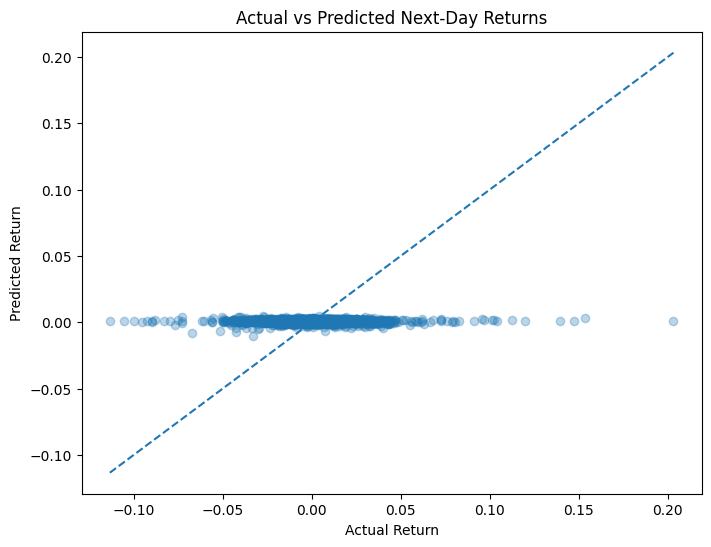

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(test_results[target_col], test_results["Predicted_Return"], alpha=0.3)

min_val = min(test_results[target_col].min(), test_results["Predicted_Return"].min())
max_val = max(test_results[target_col].max(), test_results["Predicted_Return"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Actual vs Predicted Next-Day Returns")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.show()

The baseline model predictions are heavily centered around zero,\
indicating that the model struggles to capture large movements and\
instead defaults to predicting the mean return. This suggests that\
the current feature set does not provide sufficient predictive signal for next-day returns.

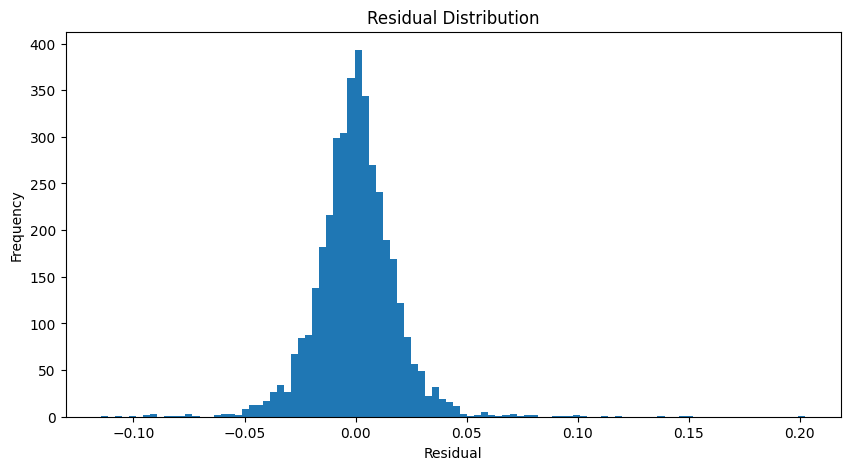

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(test_results["Residual"], bins=100)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

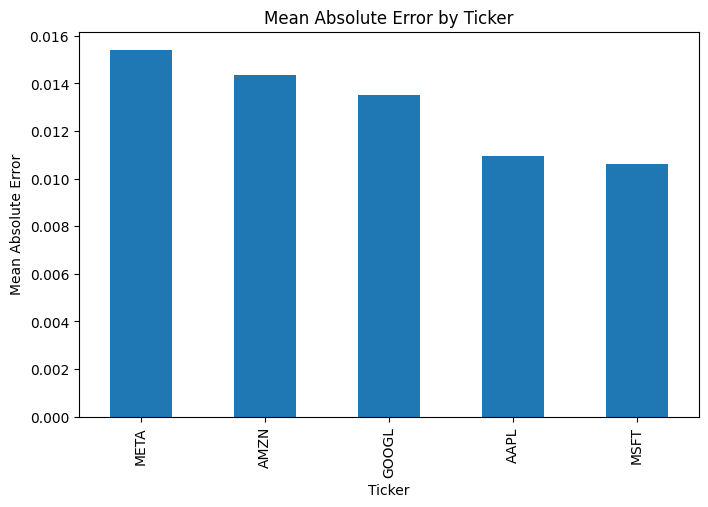

Ticker
META     0.015401
AMZN     0.014366
GOOGL    0.013529
AAPL     0.010936
MSFT     0.010610
Name: Absolute_Error, dtype: float64

In [21]:
error_by_ticker = (
    test_results.groupby("Ticker")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
error_by_ticker.plot(kind="bar")
plt.title("Mean Absolute Error by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Mean Absolute Error")
plt.show()

error_by_ticker

Okkkke,sooooo we examine the residuals and mean absolute error by ticker to better\
understand where the baseline model makes mistakes.\
What we got: The errors are centered close to zero overall, but some stocks such as\
META and AMZN show larger prediction errors than AAPL and MSFT.

In [22]:
test_results.sort_values("Absolute_Error", ascending=False)[
    ["Date", "Ticker", target_col, "Predicted_Return", "Residual", "Absolute_Error"]
].head(10)

,Date,Ticker,Target_Return_1d,Predicted_Return,Residual,Absolute_Error
15182,2024-02-01,META,0.203176,0.000667,0.202510,0.202510
3834,2025-04-08,AAPL,0.153289,0.003290,0.149999,0.149999
15478,2025-04-08,META,0.147556,0.000829,0.146727,0.146727
14989,2023-04-26,META,0.139255,0.001092,0.138163,0.138163
7915,2025-04-08,AMZN,0.119770,0.001244,0.118527,0.118527
15619,2025-10-29,META,-0.113348,0.001335,-0.114682,0.114682
15555,2025-07-30,META,0.112527,0.001714,0.110813,0.110813
15239,2024-04-24,META,-0.105613,0.000885,-0.106498,0.106498
15680,2026-01-28,META,0.104048,0.000760,0.103288,0.103288
19761,2026-01-28,MSFT,-0.099931,0.000739,-0.100670,0.100670


What we got: the biggest misses are concentrated on\
extreme return days, especially for META, which suggests that the model cannot react\
well to sudden sharp market movements.

In [27]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": baseline_model.coef_
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
4,Volume_Change_1d,0.000148
2,Return_5d,-0.002367
1,Return_3d,-0.004743
3,Volatility_5d,-0.036744
0,Return_1d,-0.036899


Baseline model coefficients show how each input feature affects the predicted next-day return.\
Recent returns and volatility have the strongest negative influence, while one-day volume change\
has only a very small positive effect.

### Baseline Takeaways

- The baseline model has very low predictive power.  
- Directional accuracy is slightly above random.
- The largest prediction errors happen on extreme return\
Model struggles most during sudden market jumps or drops.  
- For future EDA and model comparison, it will be important\
to explore richer features, ticker-specific behavior